Cassava classification experiment 9

Stronger warmup plus full-model fine-tuning from the `ex8` ResNet18 baseline.


1. Library and device setup


In [1]:
import copy
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from collections import Counter

from sklearn.model_selection import train_test_split


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)


In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cuda


2. Class count and disease name


In [3]:
COMPETITION_DATA_DIR = Path("/kaggle/input/competitions/cassava-leaf-disease-classification")
WEIGHTS_PATH = Path("/kaggle/input/datasets/sealzhao/resnet18-f37072fd-pth/resnet18-f37072fd.pth")  # Update this manually to match your attached Kaggle input
TRAIN_CSV_PATH = COMPETITION_DATA_DIR / "train.csv"
LABEL_MAP_PATH = COMPETITION_DATA_DIR / "label_num_to_disease_map.json"
TRAIN_IMAGE_DIR = COMPETITION_DATA_DIR / "train_images"
TEST_CSV_PATH = COMPETITION_DATA_DIR / "sample_submission.csv"
TEST_IMAGE_DIR = COMPETITION_DATA_DIR / "test_images"

print(f"Competition data directory: {COMPETITION_DATA_DIR}")
print(f"Offline ResNet18 checkpoint: {WEIGHTS_PATH}")

if not WEIGHTS_PATH.exists():
    raise FileNotFoundError(
        f"Offline checkpoint not found: {WEIGHTS_PATH}. Update WEIGHTS_PATH to the exact location of 'resnet18-f37072fd.pth' in your attached Kaggle input."
    )

with open(LABEL_MAP_PATH, "r") as f:
    label_num_to_disease_map = json.load(f)

train_df = pd.read_csv(TRAIN_CSV_PATH)
train_counts = Counter(train_df["label"])

print("Training set class counts:\n")
for class_idx, count in sorted(train_counts.items()):
    disease_name = label_num_to_disease_map[str(class_idx)]
    print(f"{disease_name}: {count}")


Competition data directory: /kaggle/input/competitions/cassava-leaf-disease-classification
Offline ResNet18 checkpoint: /kaggle/input/datasets/sealzhao/resnet18-f37072fd-pth/resnet18-f37072fd.pth
Training set class counts:

Cassava Bacterial Blight (CBB): 1087
Cassava Brown Streak Disease (CBSD): 2189
Cassava Green Mottle (CGM): 2386
Cassava Mosaic Disease (CMD): 13158
Healthy: 2577


3. Train and split validation distribution


In [4]:
train_df_split, valid_df_split = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label"],
    random_state=42,
)

train_counts = Counter(train_df_split["label"])
valid_counts = Counter(valid_df_split["label"])

print("Training set class counts:\n")
for class_idx, count in sorted(train_counts.items()):
    print(f"{label_num_to_disease_map[str(class_idx)]}: {count}")

print("\nValidation set class counts:\n")
for class_idx, count in sorted(valid_counts.items()):
    print(f"{label_num_to_disease_map[str(class_idx)]}: {count}")


Training set class counts:

Cassava Bacterial Blight (CBB): 870
Cassava Brown Streak Disease (CBSD): 1751
Cassava Green Mottle (CGM): 1909
Cassava Mosaic Disease (CMD): 10526
Healthy: 2061

Validation set class counts:

Cassava Bacterial Blight (CBB): 217
Cassava Brown Streak Disease (CBSD): 438
Cassava Green Mottle (CGM): 477
Cassava Mosaic Disease (CMD): 2632
Healthy: 516


4. ResNet18 setup and fine-tuning plan


This notebook keeps the `ex5` data pipeline and offline checkpoint loading, then replaces the conservative `ex8` schedule with a stronger two-stage fine-tuning plan.

Fine-tuning stages:
- `head_only`: train only the classification head for a longer warmup with a higher learning rate.
- `full_model`: unfreeze the entire ResNet18 backbone and fine-tune all layers together.

BatchNorm running statistics stay frozen only during the head warmup. Once the full model is unfrozen, BatchNorm layers are allowed to adapt normally.


In [5]:
def resolve_weights_path(weights_path=WEIGHTS_PATH):
    weights_path = Path(weights_path)

    if weights_path.is_dir():
        candidates = sorted(weights_path.rglob("resnet18-f37072fd.pth"))
        if not candidates:
            raise FileNotFoundError(
                f"No 'resnet18-f37072fd.pth' file was found under directory: {weights_path}"
            )
        resolved_path = candidates[0]
        print(f"Resolved checkpoint inside directory: {resolved_path}")
        return resolved_path

    if not weights_path.exists():
        raise FileNotFoundError(f"Offline checkpoint not found: {weights_path}")

    return weights_path


def build_model(num_classes=5, weights_path=WEIGHTS_PATH):
    resolved_weights_path = resolve_weights_path(weights_path)

    model = models.resnet18(weights=None)
    state_dict = torch.load(resolved_weights_path, map_location="cpu")
    model.load_state_dict(state_dict)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def count_trainable_parameters(model):
    return sum(param.numel() for param in model.parameters() if param.requires_grad)


In [6]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, reduction="mean", ignore_index=-100):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.reduction = reduction
        self.ignore_index = ignore_index
        self.ce = nn.CrossEntropyLoss(weight=weight, reduction="none", ignore_index=ignore_index)

    def forward(self, logits, target):
        logpt = -self.ce(logits, target)
        pt = logpt.exp()
        focal_term = (1 - pt) ** self.gamma
        loss = -focal_term * logpt

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss


def set_trainable_layers(model, mode):
    if mode == "head_only":
        for name, param in model.named_parameters():
            param.requires_grad = name.startswith("fc")
        return

    if mode == "full_model":
        for param in model.parameters():
            param.requires_grad = True
        return

    raise ValueError(f"Unsupported training mode: {mode}")


def set_batchnorm_mode(model, freeze_running_stats):
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d) and freeze_running_stats:
            module.eval()


def build_stage_optimizer(model, stage):
    if stage["mode"] == "head_only":
        return torch.optim.Adam(model.fc.parameters(), lr=stage["lr"])

    if stage["mode"] == "full_model":
        return torch.optim.Adam(model.parameters(), lr=stage["lr"])

    raise ValueError(f"Unsupported optimizer mode: {stage['mode']}")


In [7]:
model = build_model().to(device)
criterion = FocalLoss(gamma=1.0)

fine_tune_stages = [
    {
        "name": "head_only",
        "mode": "head_only",
        "epochs": 4,
        "lr": 1e-3,
        "freeze_batchnorm": True,
    },
    {
        "name": "full_model",
        "mode": "full_model",
        "epochs": 6,
        "lr": 1e-4,
        "freeze_batchnorm": False,
    },
]

for stage in fine_tune_stages:
    print(stage)


{'name': 'head_only', 'mode': 'head_only', 'epochs': 4, 'lr': 0.001, 'freeze_batchnorm': True}
{'name': 'full_model', 'mode': 'full_model', 'epochs': 6, 'lr': 0.0001, 'freeze_batchnorm': False}


5. Creating dataset class


In [8]:
class CassavaDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]["image_id"]
        label = self.df.iloc[idx]["label"]

        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


6. Train and evaluation transforms


In [9]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


7. Creating train and valid dataset


In [10]:
train_dataset = CassavaDataset(
    df=train_df_split,
    image_dir=TRAIN_IMAGE_DIR,
    transform=train_transform,
)

valid_dataset = CassavaDataset(
    df=valid_df_split,
    image_dir=TRAIN_IMAGE_DIR,
    transform=eval_transform,
)


In [11]:
pin_memory = device.type == "cuda"

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=pin_memory)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=pin_memory)


8. Training helpers


In [12]:
def train_one_epoch(model, loader, optimizer, criterion, device, freeze_batchnorm=False):
    model.train()
    set_batchnorm_mode(model, freeze_batchnorm)

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        predictions = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predictions == labels).sum().item()

    average_loss = running_loss / total
    accuracy = 100.0 * correct / total
    return average_loss, accuracy


def evaluate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * labels.size(0)
            predictions = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    average_loss = running_loss / total
    accuracy = 100.0 * correct / total
    return average_loss, accuracy


9. Stage-wise fine-tuning ResNet18


In [13]:
history = []
best_val_accuracy = 0.0
best_model_state = copy.deepcopy(model.state_dict())
best_stage_name = None
best_global_epoch = 0

global_epoch = 0
total_epochs = sum(stage["epochs"] for stage in fine_tune_stages)

for stage in fine_tune_stages:
    stage_name = stage["name"]

    set_trainable_layers(model, stage["mode"])
    optimizer = build_stage_optimizer(model, stage)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

    print(f"\nStarting stage: {stage_name}")
    print(f"Mode: {stage['mode']}")
    print(f"Learning rate: {stage['lr']}")
    print(f"Freeze BatchNorm stats: {stage['freeze_batchnorm']}")
    print(f"Trainable parameters: {count_trainable_parameters(model):,}")

    for stage_epoch in range(1, stage["epochs"] + 1):
        global_epoch += 1

        train_loss, train_accuracy = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
            freeze_batchnorm=stage["freeze_batchnorm"],
        )
        valid_loss, valid_accuracy = evaluate_model(model, valid_loader, criterion, device)

        current_lrs = [group["lr"] for group in optimizer.param_groups]
        history.append(
            {
                "stage": stage_name,
                "stage_epoch": stage_epoch,
                "global_epoch": global_epoch,
                "train_loss": train_loss,
                "train_accuracy": train_accuracy,
                "valid_loss": valid_loss,
                "valid_accuracy": valid_accuracy,
                "learning_rates": current_lrs,
            }
        )

        print(f"Epoch [{global_epoch}/{total_epochs}] ({stage_name} - {stage_epoch}/{stage['epochs']})")
        print(f"Training Loss: {train_loss:.4f}")
        print(f"Training Accuracy: {train_accuracy:.2f}%")
        print(f"Validation Loss: {valid_loss:.4f}")
        print(f"Validation Accuracy: {valid_accuracy:.2f}%")
        print(f"Current LRs: {current_lrs}\n")

        if valid_accuracy > best_val_accuracy:
            best_val_accuracy = valid_accuracy
            best_model_state = copy.deepcopy(model.state_dict())
            best_stage_name = stage_name
            best_global_epoch = global_epoch

        scheduler.step()

model.load_state_dict(best_model_state)
torch.save(best_model_state, "best_resnet18_ex9_best.pth")

print(f"Best validation accuracy: {best_val_accuracy:.2f}%")
print(f"Best stage: {best_stage_name}")
print(f"Best global epoch: {best_global_epoch}")
print("Saved best_resnet18_ex9_best.pth")



Starting stage: head_only
Mode: head_only
Learning rate: 0.001
Freeze BatchNorm stats: True
Trainable parameters: 2,565
Epoch [1/10] (head_only - 1/4)
Training Loss: 0.6203
Training Accuracy: 68.65%
Validation Loss: 0.5610
Validation Accuracy: 71.17%
Current LRs: [0.001]

Epoch [2/10] (head_only - 2/4)
Training Loss: 0.5228
Training Accuracy: 72.86%
Validation Loss: 0.5330
Validation Accuracy: 72.22%
Current LRs: [0.001]

Epoch [3/10] (head_only - 3/4)
Training Loss: 0.4953
Training Accuracy: 74.18%
Validation Loss: 0.5274
Validation Accuracy: 72.64%
Current LRs: [0.0005]

Epoch [4/10] (head_only - 4/4)
Training Loss: 0.4877
Training Accuracy: 74.56%
Validation Loss: 0.5336
Validation Accuracy: 72.92%
Current LRs: [0.0005]


Starting stage: full_model
Mode: full_model
Learning rate: 0.0001
Freeze BatchNorm stats: False
Trainable parameters: 11,179,077
Epoch [5/10] (full_model - 1/6)
Training Loss: 0.4986
Training Accuracy: 76.17%
Validation Loss: 0.4086
Validation Accuracy: 79.81%
Cur

In [14]:
history_df = pd.DataFrame(history)
history_df


,stage,stage_epoch,global_epoch,train_loss,train_accuracy,valid_loss,valid_accuracy,learning_rates
0,head_only,1,1,0.620321,68.651049,0.560983,71.168224,[0.001]
1,head_only,2,2,0.522815,72.857393,0.532963,72.219626,[0.001]
2,head_only,3,3,0.495319,74.177718,0.527435,72.640187,[0.0005]
3,head_only,4,4,0.487700,74.557457,0.533560,72.920561,[0.0005]
4,full_model,1,5,0.498648,76.169890,0.408559,79.813084,[0.0001]
5,full_model,2,6,0.284683,84.898055,0.394625,80.700935,[0.0001]
6,full_model,3,7,0.153758,91.692469,0.390388,81.728972,[5e-05]
7,full_model,4,8,0.091679,95.320442,0.434543,81.705607,[5e-05]
8,full_model,5,9,0.050214,97.557983,0.416552,82.593458,[2.5e-05]
9,full_model,6,10,0.031234,98.440147,0.438494,82.616822,[2.5e-05]


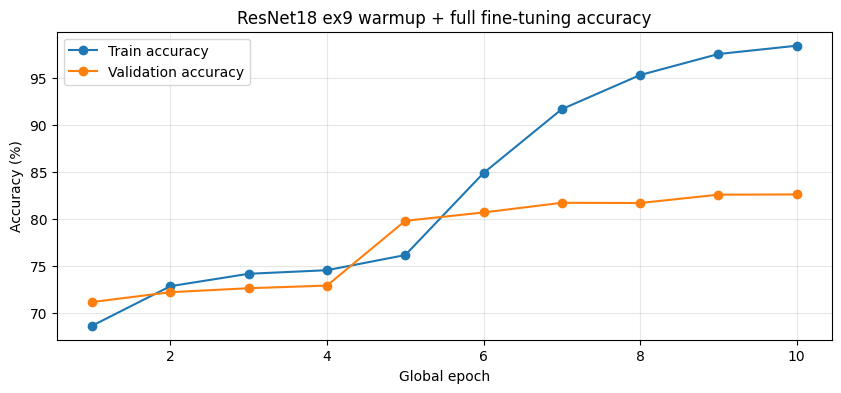

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(history_df["global_epoch"], history_df["train_accuracy"], marker="o", label="Train accuracy")
plt.plot(history_df["global_epoch"], history_df["valid_accuracy"], marker="o", label="Validation accuracy")
plt.xlabel("Global epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet18 ex9 warmup + full fine-tuning accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [16]:
test_df = pd.read_csv(TEST_CSV_PATH)


class CassavaTestDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]["image_id"]
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, img_name


test_dataset = CassavaTestDataset(test_df, TEST_IMAGE_DIR, transform=eval_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=pin_memory)

model.eval()
preds = []
ids = []
with torch.no_grad():
    for images, image_ids in test_loader:
        images = images.to(device)
        outputs = model(images)
        predicted = outputs.argmax(dim=1)
        preds.extend(predicted.cpu().numpy().tolist())
        ids.extend(image_ids)

submission = pd.DataFrame({"image_id": ids, "label": preds})
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")


Saved submission.csv


10. Next fine-tuning ideas

Suggested order after this notebook:
- If the full-model stage now beats `ex8`, compare `FocalLoss(gamma=1.0)` against `CrossEntropyLoss(label_smoothing=0.1)` next.
- If validation still peaks early, add early stopping so the notebook stops near the best epoch automatically.
- If overfitting continues, keep the ex9 schedule and test one stronger augmentation at a time, such as `RandomRotation(10)` or `ColorJitter`.
- If GPU memory allows it, compare `256x256` against `320x320` input size once the training schedule is stable.
